**生成式 AI 使用声明**：就本作业而言，使用生成式 AI 工具须遵守与合作相同的政策。与与其他合作者一样，每位学生必须独立于交互输出之外写下解决方案，且提交的作业应注明合作的性质。使用生成式 AI 工具实质性完成作业的某些部分不符合作业的精神，将违反[荣誉守则](https://communitystandards.stanford.edu/policies-and-guidance/hon-code)。

**学生声明（必须填写）**

**SUNet 学号：**  
_你的 SUNet 学号_

**你是否使用了生成式 AI 工具（如 ChatGPT、Copilot 等）？**  
- [ ] 否  
- [ ] 是（请在下方描述）

**如果是，请描述你如何使用生成式 AI 以及用于作业的哪些部分：**  
_你的回答_

**确认所有提交的作业都反映了你自己的理解，你没有依赖 AI 来完成作业的实质性部分：**  
- [ ] 我确认

# 批归一化（Batch Normalization）
使深度网络更容易训练的一种方法是使用更复杂的优化程序，如 SGD+momentum、RMSProp 或 Adam。另一种策略是改变网络架构使其更易于训练。沿着这个思路的一个想法是批归一化，由 [1] 于 2015 年提出。

为了理解批归一化的目标，首先需要认识到机器学习方法在输入数据由零均值和单位方差的不相关特征组成时往往表现更好。在训练神经网络时，我们可以在将数据输入网络之前对其进行预处理，以显式地去相关其特征。这将确保网络的第一层看到遵循良好分布的数据。然而，即使我们对输入数据进行预处理，网络较深层的激活可能不再去相关，也不再具有零均值或单位方差，因为它们是网络中较早层的输出。更糟糕的是，在训练过程中，随着每层权重的更新，网络每层特征的分布会发生变化。

[1] 的作者假设深度神经网络内部特征的分布变化可能使训练深度网络变得更加困难。为了克服这个问题，他们建议在网络中插入归一化批次的层。在训练时，这样的层使用一小批数据来估计每个特征的均值和标准差。然后使用这些估计的均值和标准差来中心化和归一化小批次的特征。在训练期间保持这些均值和标准差的运行平均值，在测试时使用这些运行平均值来中心化和归一化特征。

这种归一化策略可能会降低网络的表示能力，因为有时对于某些层来说，特征不是零均值或单位方差可能是最优的。为此，批归一化层包括每个特征维度的可学习移位和缩放参数。

[1] [Sergey Ioffe and Christian Szegedy, "Batch Normalization: Accelerating Deep Network Training by Reducing
Internal Covariate Shift", ICML 2015.](https://arxiv.org/abs/1502.03167)

In [1]:
# 设置单元格。
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # 设置默认绘图大小。
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """返回相对误差。"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

def print_mean_std(x,axis=0):
    print(f"  均值: {x.mean(axis=axis)}")
    print(f"  标准差:  {x.std(axis=axis)}\n")

Duplicate key in file WindowsPath('c:/Users/Dinking/miniconda3/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 279 ('font.sans-serif: DejaVu Sans, Bitstream Vera Sans, Computer Modern Sans Serif, Lucida Grande, Verdana, Geneva, Lucid, Arial, Helvetica, Avant Garde, sans-serif')
Duplicate key in file WindowsPath('c:/Users/Dinking/miniconda3/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 421 ('axes.unicode_minus: True  # use Unicode for the minus symbol rather than hyphen.  See')


In [2]:
# 加载（预处理后的）CIFAR-10 数据。
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

d:\Desktop\Deep_Learning\dl_assignments\assignment2\cs231n\data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


# 批归一化：前向传播
在文件 `cs231n/layers.py` 中，实现函数 `batchnorm_forward` 中的批归一化前向传播。完成后，运行以下代码测试你的实现。

参考上面 [1] 中链接的论文可能会有帮助！

In [3]:
from cs231n.layers import *

# 通过检查批归一化前后特征的均值和方差来检查训练时前向传播。

# 模拟一个两层网络的前向传播。
np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print('批归一化前:')
print_mean_std(a,axis=0)

gamma = np.ones((D3,))
beta = np.zeros((D3,))

# 均值应接近零，标准差应接近一。
print('批归一化后 (gamma=1, beta=0)')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=0)

gamma = np.asarray([1.0, 2.0, 3.0])
beta = np.asarray([11.0, 12.0, 13.0])

# 现在均值应接近 beta，标准差应接近 gamma。
print('批归一化后 (gamma=', gamma, ', beta=', beta, ')')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=0)

批归一化前:
  均值: [ -2.3814598  -13.18038246   1.91780462]
  标准差:  [27.18502186 34.21455511 37.68611762]

批归一化后 (gamma=1, beta=0)
  均值: [4.88498131e-17 6.93889390e-17 4.42007542e-17]
  标准差:  [0.99999999 1.         1.        ]

批归一化后 (gamma= [1. 2. 3.] , beta= [11. 12. 13.] )
  均值: [11. 12. 13.]
  标准差:  [0.99999999 1.99999999 2.99999999]



In [4]:
# 通过多次运行训练时前向传播来预热运行平均值，然后
# 检查测试时前向传播后激活的均值和方差，以此来检查测试时前向传播。

np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)

bn_param = {'mode': 'train'}
gamma = np.ones(D3)
beta = np.zeros(D3)

for t in range(50):
  X = np.random.randn(N, D1)
  a = np.maximum(0, X.dot(W1)).dot(W2)
  batchnorm_forward(a, gamma, beta, bn_param)

bn_param['mode'] = 'test'
X = np.random.randn(N, D1)
a = np.maximum(0, X.dot(W1)).dot(W2)
a_norm, _ = batchnorm_forward(a, gamma, beta, bn_param)

# 均值应接近零，标准差接近一，但会比训练时前向传播更嘈杂。
print('批归一化后 (测试时):')
print_mean_std(a_norm,axis=0)

批归一化后 (测试时):
  均值: [ 1.55431223e-17 -2.35922393e-17 -1.02140518e-16]
  标准差:  [1. 1. 1.]



# 批归一化：反向传播
现在在函数 `batchnorm_backward` 中实现批归一化的反向传播。

为了推导反向传播，你应该写出批归一化的计算图，并通过每个中间节点进行反向传播。某些中间节点可能有多个出分支；确保在反向传播中对这些分支的梯度求和。参考上面 [1] 中链接的论文可能会有帮助！

完成后，运行以下代码用数值方法检查你的反向传播。

_提示：[这个资源](https://www.adityaagrawal.net/blog/deep_learning/bprop_batch_norm) 解释了如何从论文中推导梯度，非常有用。_

In [5]:
# 批归一化反向传播的梯度检查。
from importlib import reload
import cs231n.layers
reload(cs231n.layers)
from cs231n.layers import *

np.random.seed(231)
N, D = 4, 5
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
fx = lambda x: batchnorm_forward(x, gamma, beta, bn_param)[0]
fg = lambda a: batchnorm_forward(x, a, beta, bn_param)[0]
fb = lambda b: batchnorm_forward(x, gamma, b, bn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma.copy(), dout)
db_num = eval_numerical_gradient_array(fb, beta.copy(), dout)

_, cache = batchnorm_forward(x, gamma, beta, bn_param)
dx, dgamma, dbeta = batchnorm_backward(dout, cache)

# 你应该看到相对误差在 1e-13 到 1e-8 之间。
print('dx 误差: ', rel_error(dx_num, dx))
print('dgamma 误差: ', rel_error(da_num, dgamma))
print('dbeta 误差: ', rel_error(db_num, dbeta))

dx 误差:  1.702926968594948e-09
dgamma 误差:  7.420414216247087e-13
dbeta 误差:  2.8795057655839487e-12


# 批归一化：替代反向传播
在课堂上我们讨论了两种不同的 sigmoid 反向传播实现。一种策略是写出由简单操作组成的计算图，并通过所有中间值进行反向传播。另一种策略是在纸上推导导数。例如，你可以通过在纸上简化梯度来推导 sigmoid 函数反向传播的非常简单的公式。

令人惊讶的是，批归一化的反向传播也可以进行类似的简化！

在前向传播中，给定一组输入 $X=\begin{bmatrix}x_1\\x_2\\...\\x_N\end{bmatrix}$，

我们首先计算均值 $\mu$ 和方差 $v$。
计算完 $\mu$ 和 $v$ 后，我们可以计算标准差 $\sigma$ 和归一化数据 $Y$。
下面的方程和图示描述了计算过程（$y_i$ 是向量 $Y$ 的第 i 个元素）。

\begin{align}
& \mu=\frac{1}{N}\sum_{k=1}^N x_k  &  v=\frac{1}{N}\sum_{k=1}^N (x_k-\mu)^2 \\
& \sigma=\sqrt{v+\epsilon}         &  y_i=\frac{x_i-\mu}{\sigma}
\end{align}

<img src="https://raw.githubusercontent.com/cs231n/cs231n.github.io/master/assets/a2/batchnorm_graph.png">

在反向传播期间，我们的核心问题是在给定上游梯度 $\frac{\partial L}{\partial Y}$ 的情况下计算 $\frac{\partial L}{\partial X}$。为此，回忆微积分中的链式法则给出 $\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y} \cdot \frac{\partial Y}{\partial X}$。

未知/困难的部分是 $\frac{\partial Y}{\partial X}$。我们可以通过首先逐步推导局部梯度来找到它：
$\frac{\partial v}{\partial X}$、$\frac{\partial \mu}{\partial X}$、
$\frac{\partial \sigma}{\partial v}$、
$\frac{\partial Y}{\partial \sigma}$ 和 $\frac{\partial Y}{\partial \mu}$，
然后使用链式法则适当地组合这些梯度（它们以向量的形式出现！）来计算 $\frac{\partial Y}{\partial X}$。

如果直接推理 $X$ 和 $Y$ 上的梯度（需要矩阵乘法）具有挑战性，尝试首先以单个元素 $x_i$ 和 $y_i$ 的形式来推理梯度：在这种情况下，你需要依靠链式法则首先计算中间量 $\frac{\partial \mu}{\partial x_i}$、$\frac{\partial v}{\partial x_i}$、$\frac{\partial \sigma}{\partial x_i}$，然后将这些部分组合起来计算 $\frac{\partial y_i}{\partial x_i}$。

你应该确保每个中间梯度的推导都尽可能简化，以便于实现。

完成后，在函数 `batchnorm_backward_alt` 中实现简化的批归一化反向传播，并通过运行以下代码比较两种实现。你的两种实现应该计算出几乎相同的结果，但替代实现应该稍快一些。

_提示：https://cs.stanford.edu/people/jcjohns/batchnorm.pdf。注意 γ 应在最终推导中被考虑。_

_请注意，此 pdf 中的方程 (8) 应为：_
$$\frac{1}{\sigma} \frac{\partial}{\partial x_i} (x_j - \mu)
- \frac{1}{\sigma^2} \frac{\partial \sigma}{\partial x_i} (x_j - \mu)$$

In [6]:
np.random.seed(231)
N, D = 100, 500
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
out, cache = batchnorm_forward(x, gamma, beta, bn_param)

t1 = time.time()
dx1, dgamma1, dbeta1 = batchnorm_backward(dout, cache)
t2 = time.time()
dx2, dgamma2, dbeta2 = batchnorm_backward_alt(dout, cache)
t3 = time.time()

print('dx 差异: ', rel_error(dx1, dx2))
print('dgamma 差异: ', rel_error(dgamma1, dgamma2))
print('dbeta 差异: ', rel_error(dbeta1, dbeta2))
print('加速比: %.2fx' % ((t2 - t1) / (t3 - t2)))

dx 差异:  0.0
dgamma 差异:  0.0
dbeta 差异:  0.0
加速比: 1.26x


# 使用批归一化的全连接网络
现在你已经有了可工作的批归一化实现，回到文件 `cs231n/classifiers/fc_net.py` 中的 `FullyConnectedNet`。回想一下，你在作业 1 中实现了网络的初始化、前向传播和反向传播。将其实现复制到这里，并修改它以融入批归一化。

具体来说，当构造函数中的 `normalization` 标志设置为 `"batchnorm"` 时，你应该在每个 ReLU 非线性之前插入一个批归一化层。网络的最后一层输出不应被归一化。完成后，运行以下代码来梯度检查你的实现。

**提示：** 你可能会发现定义一个额外的辅助层（类似于文件 `cs231n/layer_utils.py` 中的层）很有用。

In [7]:
from cs231n.classifiers.fc_net import *
from cs231n.gradient_check import *

np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

# W 的期望损失应在 1e-4~1e-10 之间，
# b 的期望损失应在 1e-08~1e-10 之间，
# beta 和 gamma 的期望损失应在 1e-08~1e-09 之间。
for reg in [0, 3.14]:
  print('Running check with reg = ', reg)
  model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                            reg=reg, weight_scale=5e-2, dtype=np.float64,
                            normalization='batchnorm')

  loss, grads = model.loss(X, y)
  print('Initial loss: ', loss)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
  if reg == 0: print()

Running check with reg =  0
Initial loss:  2.2611955101340957
W1 relative error: 1.10e-04
W2 relative error: 3.07e-06
W3 relative error: 3.92e-10
b1 relative error: 1.78e-07
b2 relative error: 2.00e-07
b3 relative error: 9.06e-11
beta1 relative error: 7.85e-09
beta2 relative error: 1.89e-09
gamma1 relative error: 7.47e-09
gamma2 relative error: 3.35e-09

Running check with reg =  3.14
Initial loss:  6.996533220108303
W1 relative error: 1.98e-06
W2 relative error: 2.28e-06
W3 relative error: 1.11e-08
b1 relative error: 4.44e-08
b2 relative error: 1.78e-07
b3 relative error: 1.73e-10
beta1 relative error: 6.65e-09
beta2 relative error: 3.48e-09
gamma1 relative error: 5.94e-09
gamma2 relative error: 4.67e-09


# 批归一化用于深度网络
运行以下代码来训练一个六层网络，使用 1000 个训练样本的子集，分别在有和没有批归一化的情况下进行训练。

In [8]:
np.random.seed(231)

# 尝试用批归一化训练一个非常深的网络。
hidden_dims = [100, 100, 100, 100, 100]

num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

weight_scale = 2e-2
bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization='batchnorm')
model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)

print('使用批归一化的求解器：')
bn_solver = Solver(bn_model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True,print_every=20)
bn_solver.train()

print('\n不使用批归一化的求解器：')
solver = Solver(model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=20)
solver.train()

使用批归一化的求解器：
(Iteration 1 / 200) loss: 2.340974
(Epoch 0 / 10) train acc: 0.137000; val_acc: 0.133000
(Epoch 1 / 10) train acc: 0.328000; val_acc: 0.283000
(Iteration 21 / 200) loss: 2.039345
(Epoch 2 / 10) train acc: 0.412000; val_acc: 0.295000
(Iteration 41 / 200) loss: 2.047471
(Epoch 3 / 10) train acc: 0.473000; val_acc: 0.321000
(Iteration 61 / 200) loss: 1.739554
(Epoch 4 / 10) train acc: 0.507000; val_acc: 0.311000
(Iteration 81 / 200) loss: 1.246973
(Epoch 5 / 10) train acc: 0.571000; val_acc: 0.341000
(Iteration 101 / 200) loss: 1.354766
(Epoch 6 / 10) train acc: 0.639000; val_acc: 0.325000
(Iteration 121 / 200) loss: 1.014048
(Epoch 7 / 10) train acc: 0.693000; val_acc: 0.336000
(Iteration 141 / 200) loss: 1.135644
(Epoch 8 / 10) train acc: 0.725000; val_acc: 0.325000
(Iteration 161 / 200) loss: 0.652408
(Epoch 9 / 10) train acc: 0.778000; val_acc: 0.354000
(Iteration 181 / 200) loss: 0.793026
(Epoch 10 / 10) train acc: 0.765000; val_acc: 0.302000

不使用批归一化的求解器：
(Iteration 1 / 

运行以下代码来可视化上面训练的两个网络的结果。你应该发现使用批归一化有助于网络更快地收敛。

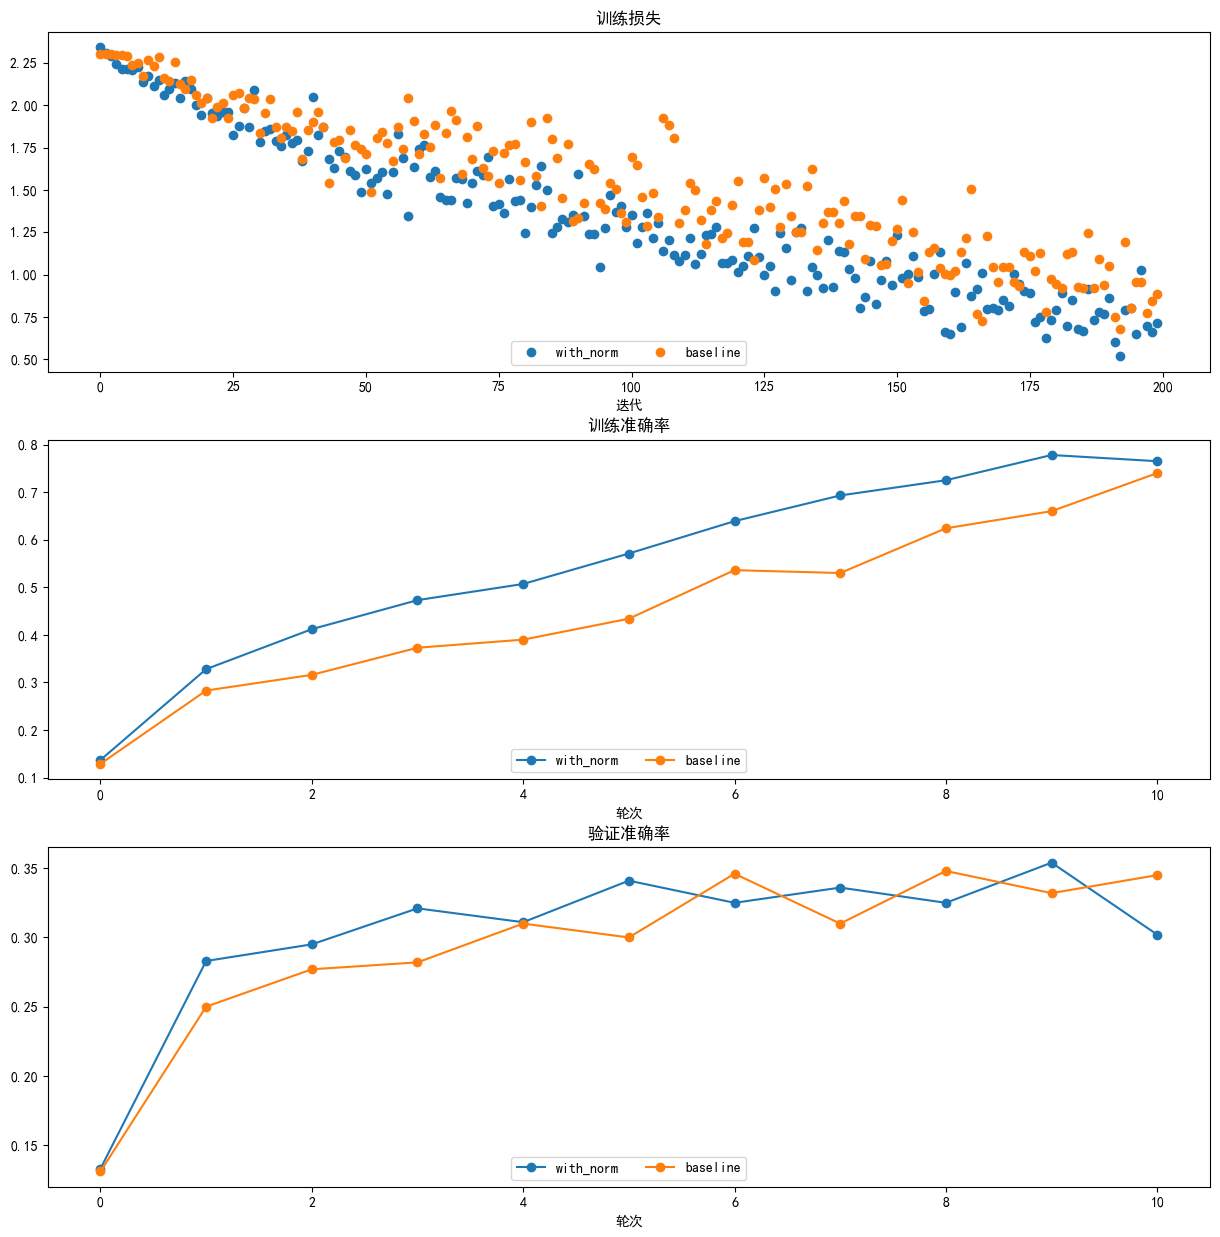

In [9]:
def plot_training_history(title, label, baseline, bn_solvers, plot_fn, bl_marker='.', bn_marker='.', labels=None):
    """用于绘制训练历史的工具函数"""
    plt.title(title)
    plt.xlabel(label)
    bn_plots = [plot_fn(bn_solver) for bn_solver in bn_solvers]
    bl_plot = plot_fn(baseline)
    num_bn = len(bn_plots)
    for i in range(num_bn):
        label='with_norm'
        if labels is not None:
            label += str(labels[i])
        plt.plot(bn_plots[i], bn_marker, label=label)
    label='baseline'
    if labels is not None:
        label += str(labels[0])
    plt.plot(bl_plot, bl_marker, label=label)
    plt.legend(loc='lower center', ncol=num_bn+1)


plt.subplot(3, 1, 1)
plot_training_history('训练损失','迭代', solver, [bn_solver], \
                      lambda x: x.loss_history, bl_marker='o', bn_marker='o')
plt.subplot(3, 1, 2)
plot_training_history('训练准确率','轮次', solver, [bn_solver], \
                      lambda x: x.train_acc_history, bl_marker='-o', bn_marker='-o')
plt.subplot(3, 1, 3)
plot_training_history('验证准确率','轮次', solver, [bn_solver], \
                      lambda x: x.val_acc_history, bl_marker='-o', bn_marker='-o')

plt.gcf().set_size_inches(15, 15)
plt.show()

# 批归一化与初始化
我们现在将运行一个小实验来研究批归一化和权重初始化的相互作用。

第一个单元格将使用不同的权重初始化尺度训练带有和不带有批归一化的八层网络。第二个单元格将绘制训练准确率、验证集准确率和训练损失随权重初始化尺度变化的函数。

In [10]:
np.random.seed(231)

# 尝试用批归一化训练一个非常深的网络。
hidden_dims = [50, 50, 50, 50, 50, 50, 50]
num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

bn_solvers_ws = {}
solvers_ws = {}
weight_scales = np.logspace(-4, 0, num=20)
for i, weight_scale in enumerate(weight_scales):
    print('Running weight scale %d / %d' % (i + 1, len(weight_scales)))
    bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization='batchnorm')
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)

    bn_solver = Solver(bn_model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    bn_solver.train()
    bn_solvers_ws[weight_scale] = bn_solver

    solver = Solver(model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    solver.train()
    solvers_ws[weight_scale] = solver

Running weight scale 1 / 20
Running weight scale 2 / 20
Running weight scale 3 / 20
Running weight scale 4 / 20
Running weight scale 5 / 20
Running weight scale 6 / 20
Running weight scale 7 / 20
Running weight scale 8 / 20
Running weight scale 9 / 20
Running weight scale 10 / 20
Running weight scale 11 / 20
Running weight scale 12 / 20
Running weight scale 13 / 20
Running weight scale 14 / 20
Running weight scale 15 / 20
Running weight scale 16 / 20


d:\Desktop\Deep_Learning\dl_assignments\assignment2\cs231n\layers.py:97: RuntimeWarning: divide by zero encountered in log
  loss = np.mean(-np.log(probs[np.arange(N), y]))


Running weight scale 17 / 20
Running weight scale 18 / 20
Running weight scale 19 / 20
Running weight scale 20 / 20


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

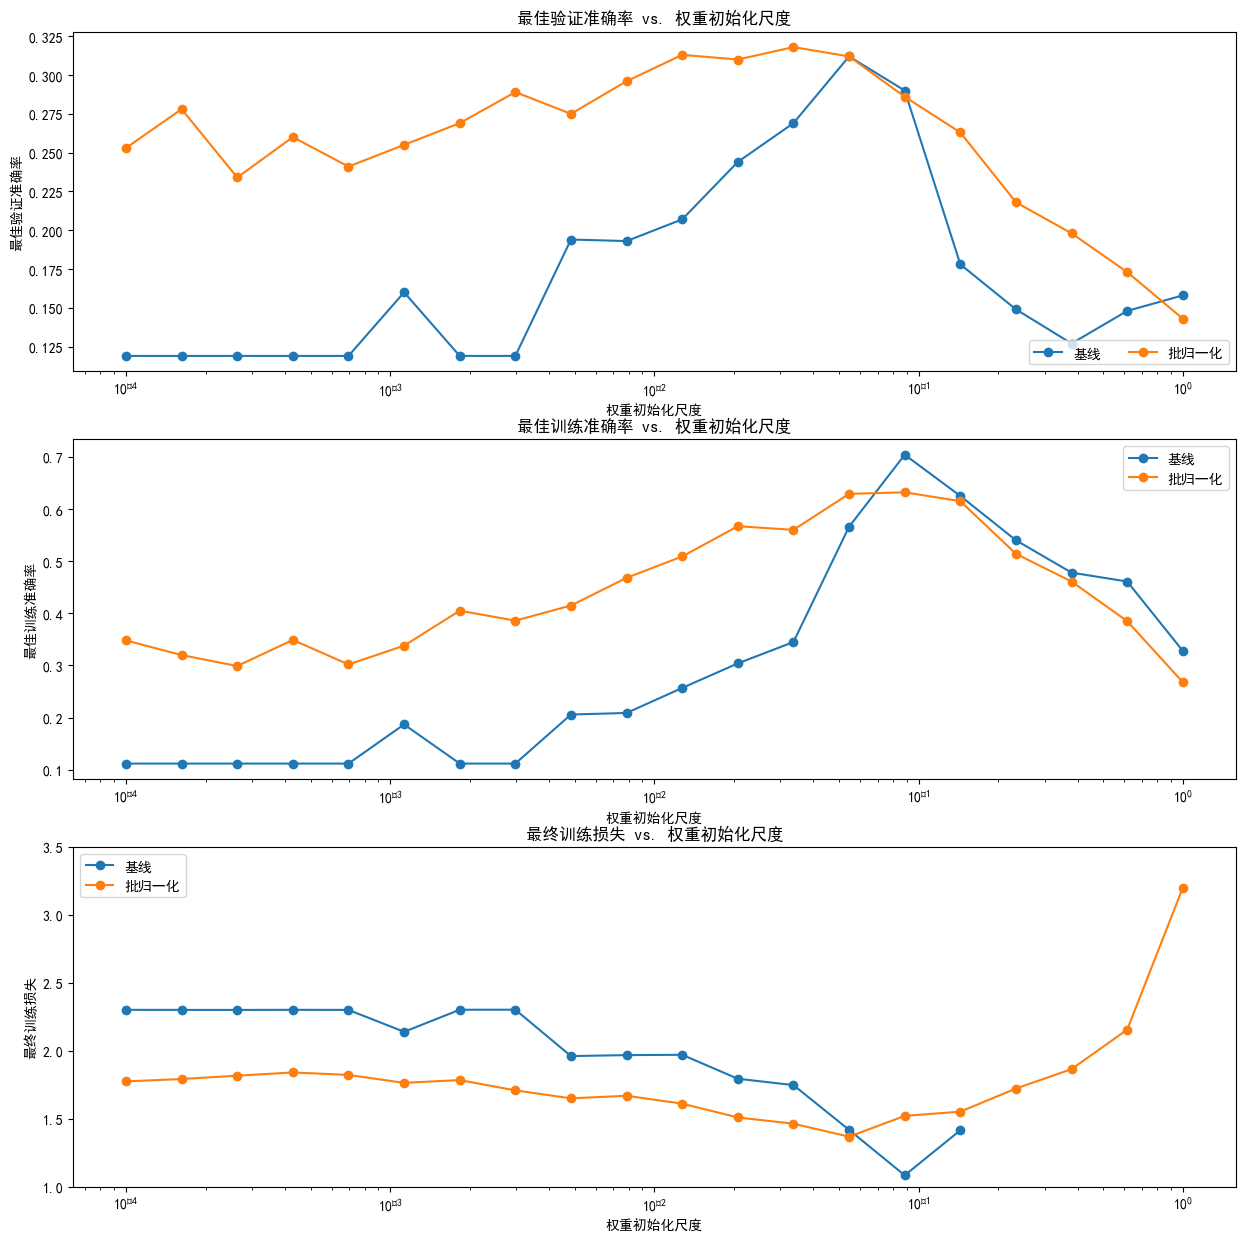

In [11]:
# 绘制权重尺度实验的结果。
best_train_accs, bn_best_train_accs = [], []
best_val_accs, bn_best_val_accs = [], []
final_train_loss, bn_final_train_loss = [], []

for ws in weight_scales:
  best_train_accs.append(max(solvers_ws[ws].train_acc_history))
  bn_best_train_accs.append(max(bn_solvers_ws[ws].train_acc_history))

  best_val_accs.append(max(solvers_ws[ws].val_acc_history))
  bn_best_val_accs.append(max(bn_solvers_ws[ws].val_acc_history))

  final_train_loss.append(np.mean(solvers_ws[ws].loss_history[-100:]))
  bn_final_train_loss.append(np.mean(bn_solvers_ws[ws].loss_history[-100:]))

plt.subplot(3, 1, 1)
plt.title('最佳验证准确率 vs. 权重初始化尺度')
plt.xlabel('权重初始化尺度')
plt.ylabel('最佳验证准确率')
plt.semilogx(weight_scales, best_val_accs, '-o', label='基线')
plt.semilogx(weight_scales, bn_best_val_accs, '-o', label='批归一化')
plt.legend(ncol=2, loc='lower right')

plt.subplot(3, 1, 2)
plt.title('最佳训练准确率 vs. 权重初始化尺度')
plt.xlabel('权重初始化尺度')
plt.ylabel('最佳训练准确率')
plt.semilogx(weight_scales, best_train_accs, '-o', label='基线')
plt.semilogx(weight_scales, bn_best_train_accs, '-o', label='批归一化')
plt.legend()

plt.subplot(3, 1, 3)
plt.title('最终训练损失 vs. 权重初始化尺度')
plt.xlabel('权重初始化尺度')
plt.ylabel('最终训练损失')
plt.semilogx(weight_scales, final_train_loss, '-o', label='基线')
plt.semilogx(weight_scales, bn_final_train_loss, '-o', label='批归一化')
plt.legend()
plt.gca().set_ylim(1.0, 3.5)

plt.gcf().set_size_inches(15, 15)
plt.show()

## 思考题 1：
描述这个实验的结果。权重初始化尺度如何不同地影响带有/不带有批归一化的模型，为什么？

## 回答：
[在此填写]

# 批归一化与批次大小
我们现在将运行一个小实验来研究批归一化和批次大小的相互作用。

第一个单元格将使用不同的批次大小训练带有和不带有批归一化的 6 层网络。第二个单元格将随时间绘制训练准确率和验证集准确率。

In [12]:
def run_batchsize_experiments(normalization_mode):
    np.random.seed(231)

    # 尝试用批归一化训练一个非常深的网络。
    hidden_dims = [100, 100, 100, 100, 100]
    num_train = 1000
    small_data = {
      'X_train': data['X_train'][:num_train],
      'y_train': data['y_train'][:num_train],
      'X_val': data['X_val'],
      'y_val': data['y_val'],
    }
    n_epochs=10
    weight_scale = 2e-2
    batch_sizes = [5,10,50]
    lr = 10**(-3.5)
    solver_bsize = batch_sizes[0]

    print('无归一化: batch size = ',solver_bsize)
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)
    solver = Solver(model, small_data,
                    num_epochs=n_epochs, batch_size=solver_bsize,
                    update_rule='adam',
                    optim_config={
                      'learning_rate': lr,
                    },
                    verbose=False)
    solver.train()

    bn_solvers = []
    for i in range(len(batch_sizes)):
        b_size=batch_sizes[i]
        print('归一化: batch size = ',b_size)
        bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=normalization_mode)
        bn_solver = Solver(bn_model, small_data,
                        num_epochs=n_epochs, batch_size=b_size,
                        update_rule='adam',
                        optim_config={
                          'learning_rate': lr,
                        },
                        verbose=False)
        bn_solver.train()
        bn_solvers.append(bn_solver)

    return bn_solvers, solver, batch_sizes

batch_sizes = [5,10,50]
bn_solvers_bsize, solver_bsize, batch_sizes = run_batchsize_experiments('batchnorm')

无归一化: batch size =  5


KeyboardInterrupt: 

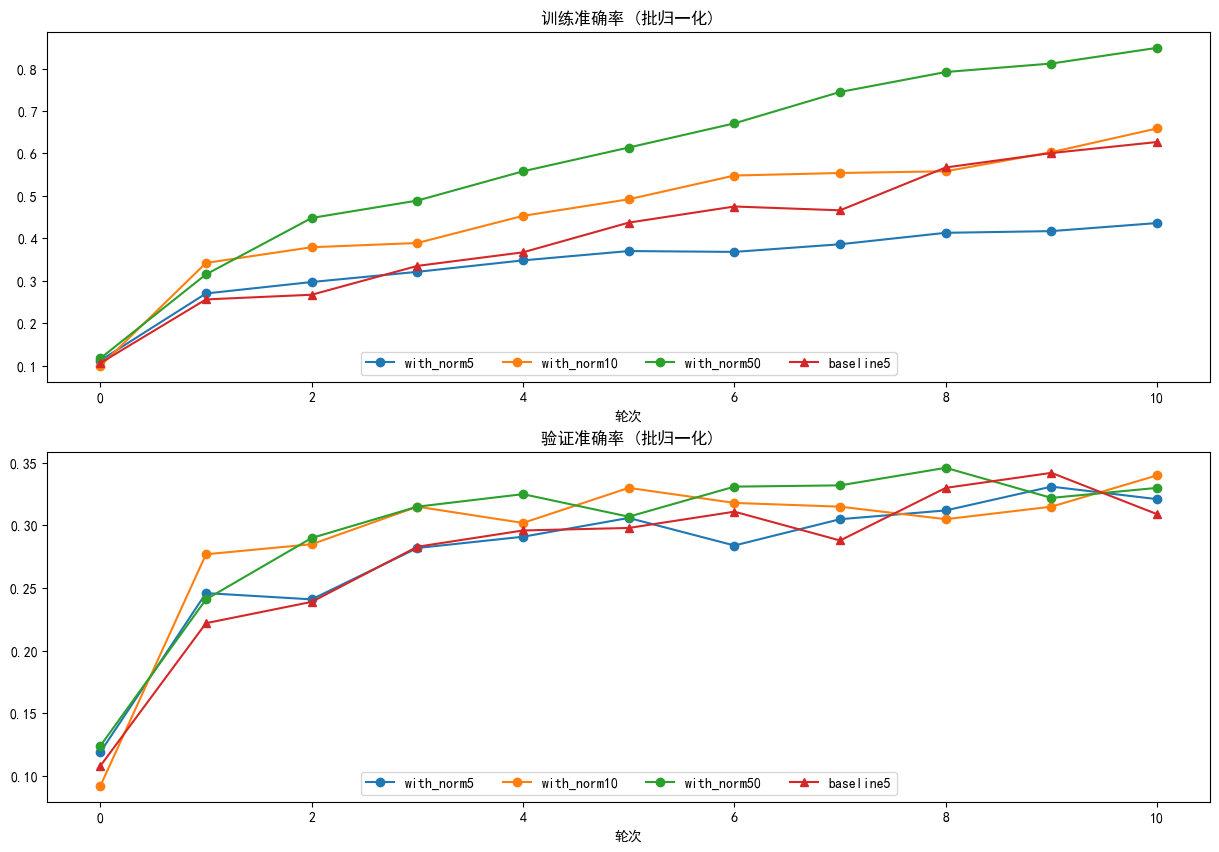

In [ ]:
plt.subplot(2, 1, 1)
plot_training_history('训练准确率 (批归一化)','轮次', solver_bsize, bn_solvers_bsize, \
                      lambda x: x.train_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.subplot(2, 1, 2)
plot_training_history('验证准确率 (批归一化)','轮次', solver_bsize, bn_solvers_bsize, \
                      lambda x: x.val_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)

plt.gcf().set_size_inches(15, 10)
plt.show()

## 思考题 2：
描述这个实验的结果。这暗示了批归一化和批次大小之间的关系是什么？为什么会观察到这种关系？

## 回答：
[在此填写]

# 层归一化（Layer Normalization）
批归一化已被证明在使网络更易于训练方面非常有效，但对批次大小的依赖使其在由于硬件限制而对输入批次大小有上限的复杂网络中不太有用。

已经提出了几种批归一化的替代方案来缓解这个问题；其中一种技术是层归一化 [2]。不同于在批次上归一化，我们在特征上归一化。换句话说，当使用层归一化时，对应于单个数据点的每个特征向量基于该特征向量内所有项的总和进行归一化。

[2] [Ba, Jimmy Lei, Jamie Ryan Kiros, and Geoffrey E. Hinton. "Layer Normalization." stat 1050 (2016): 21.](https://arxiv.org/pdf/1607.06450.pdf)

## 思考题 3：
以下哪些数据预处理步骤类似于批归一化，哪些类似于层归一化？

1. 缩放数据集中的每张图像，使图像中每行像素的 RGB 通道之和为 1。
2. 缩放数据集中的每张图像，使图像中所有像素的 RGB 通道之和为 1。
3. 从数据集中的每张图像中减去数据集的均值图像。
4. 根据给定阈值将所有 RGB 值设置为 0 或 1。

## 回答：
[在此填写]

# 层归一化：实现

现在你将实现层归一化。这一步应该相对简单，因为概念上实现几乎与批归一化完全相同。不过一个显著的区别是，对于层归一化，我们不跟踪移动矩，测试阶段与训练阶段相同，直接对每个数据点计算均值和方差。

你需要做以下事情：

* 在 `cs231n/layers.py` 中，实现函数 `layernorm_forward` 中层归一化的前向传播。

运行下面的单元格来检查结果。
* 在 `cs231n/layers.py` 中，实现函数 `layernorm_backward` 中层归一化的反向传播。

运行第二个单元格来检查结果。
* 修改 `cs231n/classifiers/fc_net.py`，将层归一化添加到 `FullyConnectedNet` 中。当构造函数中的 `normalization` 标志设置为 `"layernorm"` 时，你应该在每个 ReLU 非线性之前插入一个层归一化层。

运行第三个单元格来对层归一化运行批次大小实验。

In [ ]:
# 通过检查层归一化前后特征的均值和方差来检查训练时前向传播。

# 模拟一个两层网络的前向传播。
np.random.seed(231)
N, D1, D2, D3 =4, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print('层归一化前:')
print_mean_std(a,axis=1)

gamma = np.ones(D3)
beta = np.zeros(D3)

# 均值应接近零，标准差应接近一。
print('层归一化后 (gamma=1, beta=0)')
a_norm, _ = layernorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=1)

gamma = np.asarray([3.0,3.0,3.0])
beta = np.asarray([5.0,5.0,5.0])

# 现在均值应接近 beta，标准差应接近 gamma。
print('层归一化后 (gamma=', gamma, ', beta=', beta, ')')
a_norm, _ = layernorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=1)

层归一化前:
  均值: [-59.06673243 -47.60782686 -43.31137368 -26.40991744]
  标准差:  [10.07429373 28.39478981 35.28360729  4.01831507]

层归一化后 (gamma=1, beta=0)


AttributeError: 'NoneType' object has no attribute 'mean'

In [ ]:
# 层归一化反向传播的梯度检查。
np.random.seed(231)
N, D = 4, 5
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

ln_param = {}
fx = lambda x: layernorm_forward(x, gamma, beta, ln_param)[0]
fg = lambda a: layernorm_forward(x, a, beta, ln_param)[0]
fb = lambda b: layernorm_forward(x, gamma, b, ln_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma.copy(), dout)
db_num = eval_numerical_gradient_array(fb, beta.copy(), dout)

_, cache = layernorm_forward(x, gamma, beta, ln_param)
dx, dgamma, dbeta = layernorm_backward(dout, cache)

# 你应该看到相对误差在 1e-12 到 1e-8 之间。
print('dx 误差: ', rel_error(dx_num, dx))
print('dgamma 误差: ', rel_error(da_num, dgamma))
print('dbeta 误差: ', rel_error(db_num, dbeta))

# 层归一化与批次大小

我们现在将用层归一化代替批归一化运行之前的批次大小实验。与之前的实验相比，你应该看到批次大小对训练历史的影响明显更小！

In [ ]:
ln_solvers_bsize, solver_bsize, batch_sizes = run_batchsize_experiments('layernorm')

plt.subplot(2, 1, 1)
plot_training_history('训练准确率 (层归一化)','轮次', solver_bsize, ln_solvers_bsize, \
                      lambda x: x.train_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.subplot(2, 1, 2)
plot_training_history('验证准确率 (层归一化)','轮次', solver_bsize, ln_solvers_bsize, \
                      lambda x: x.val_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)

plt.gcf().set_size_inches(15, 10)
plt.show()

## 思考题 4：
在什么情况下层归一化可能效果不好，为什么？

1. 在一个非常深的网络中使用它
2. 特征的维度非常小
3. 正则化项很高


## 回答：
[在此填写]

In [ ]:
import matplotlib
print(matplotlib.matplotlib_fname())


c:\Users\Dinking\miniconda3\Lib\site-packages\matplotlib\mpl-data\matplotlibrc
